# S08: Taylor Polynomials

In [2]:
import numpy as np
import sympy as sy
import matplotlib.pyplot as plt
from sympy import Function, diff, Symbol, latex
from sympy.plotting import plot
from IPython.display import Math, display

# Basic Taylor polynomial computations

Let us recall how to use sympy to compute symbolic derivatives, like the ones in the exercises for this section. We will use this function for the examples below, but you are invited to try and experiment with other examples:
$$f(x) = e^{\cos 2x}$$

In [42]:
x = sy.Symbol('x', real=True)
f = (x + 2) * sy.exp(x)
print(f"f(x)  = {f}")


f(x)  = (x + 2)*exp(x)


Now we can get the Taylor polynomial for a given order $n$. The exercises ask for $n = 3$, but with sympy we can just as easily start with $n = 5$.

In [43]:
n = 5
Pnf = sy.series(f, x, 0, n+1).removeO()
display(Math(f"P_{ {n} }(x) = {latex(Pnf)}"))

<IPython.core.display.Math object>

* Note that the function we use is not called Taylor or something similar, but `series`. We will see later in the course the reasons behind this name.
* What is this `removeO` that we have included? It is related with the *size of the error* when we use the Taylor polynomial to approximate $f$ near $x_0$. We will explore that below. For now, simply remove it to see the change in the output:

In [44]:
display(Math(f"{latex(sy.series(f, x, 0, n+1))}"))


<IPython.core.display.Math object>

The last term in this expression is an **error term**.

# Approximating the function by its Taylor polynomial: graphic version.

Let us plot the function together with its first Taylor polynomials. For this plot we switch to the numeric version (numpy) of the objects, so that we can use matplotlib (more flexible than sympy plotting).

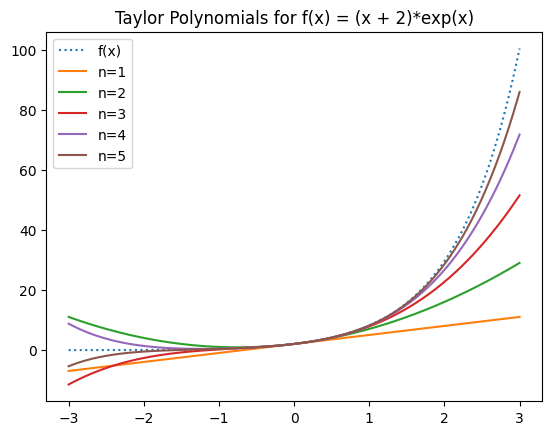

In [45]:
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(-3, 3, 400)
f_num = sy.lambdify(x, f, 'numpy')

fig, ax = plt.subplots()
ax.plot(xs, f_num(xs), label='f(x)', linestyle=':')

for i in range(1, n + 1):
    Pni = sy.series(f, x, 0, i + 1).removeO()
    Pni_num = sy.lambdify(x, Pni, 'numpy')
    ax.plot(xs, Pni_num(xs), label=f'n={i}')

ax.legend()
ax.set_title(f'Taylor Polynomials for f(x) = {f}')
plt.show()

This plot *hints* at the idea that the approximation gets better if:

*   we get closer to $x_0$
*   we increase the order $n$ of the polynomial.

But this static Python plot is not optimal for that. It is faster and easier to tun this experiment with the following <a href="https://www.geogebra.org/m/bnqzrhch" target="_blank" rel="noopener noreferrer">GeoGebra construction (opens in new tab).</a>



# Order of infinitesimals

The goal of the code below is to illustrate that, given an infinitesimal $f(x)$ at $x_0$, you need to choose $A$ and $p$ carefully in order to get the following result:
$$
\lim_{x\to x_0}\dfrac{f(x)}{A\, (x - x_0)^p} = 1
$$
Initially the limit is not 1, and you need to play with $A$ and $p$ until you get the desired result.

**Hints:**

1) To make your search easir, the desired $p$ and $A$ are natural numbers $1, 2, 3,\ldots$
2) Begin locating $p$. How do you know you have found the right value?

In [46]:
x = sy.Symbol('x')
f = sy.sqrt(1 + sy.sin(x-2)**5) - sy.exp(sy.cos(3*(x - 2)**4) - 1)
display(Math(f"f(x) = {latex(f)}"))

<IPython.core.display.Math object>

First we plot f near 2 to visually check that f is an infinitesimal at $x_0 = 2$

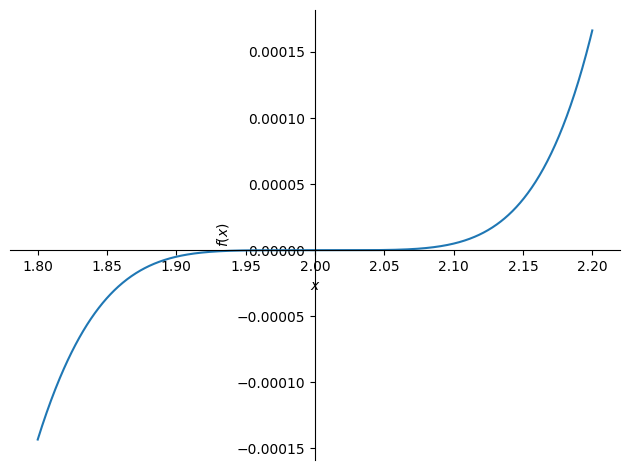

In [47]:
plot_range = (x, 1.8, 2.2) # Centered around x=2
p = sy.plotting.plot(f, plot_range, show=False)
p.show()

We can more formally check this by computing the limit:

In [48]:
# Limit of f at 2
limit_f = sy.limit(f, x, 2)
display(Math(f"\\lim_{{x \\to 2}} f(x) = {sy.latex(limit_f)}"))

<IPython.core.display.Math object>

If you have thought you can do the same by substituting 2 into $f$, that is correct because $f$ is continuous at $2$.

In [49]:
f.subs(x, 2)

0

In [50]:
sy.series(f, x, 2, 10).removeO()

23*(x - 2)**9/144 + 9*(x - 2)**8/2 - 5*(x - 2)**7/12 + (x - 2)**5/2

**Now begins the real fun!** Experiment with the values of $A$ and $p$ until you get the limit equal to 1.


In [51]:
p = 3
A = 7
InfStd = A * (x - 2)**p



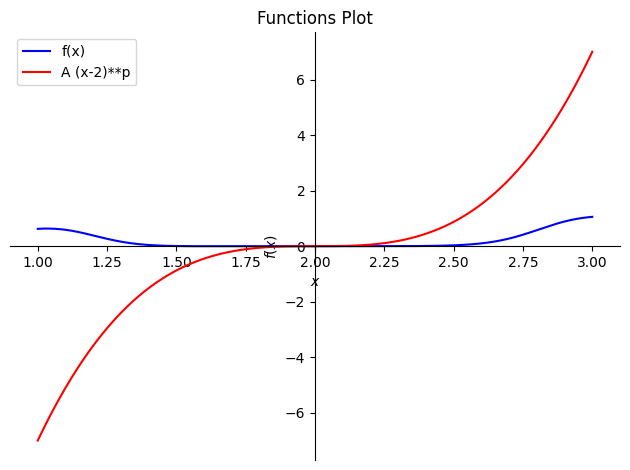

In [52]:
plot_range = (x, 1, 3) # Centered around x=2
p = sy.plotting.plot(f, InfStd, plot_range, show=False, legend=True)
p[0].line_color = 'blue'
p[0].label = 'f(x)'
p[1].line_color = 'red'
p[1].label = 'A (x-2)**p'
p.title = 'Functions Plot'

p.show()

Do not proceed blindly! Look at the plot and make an educated guess. And also, if you get $\infty$ out of the limit, what do you have to do with $p$? And what if you get $0$?

In [53]:
limit_quotient = sy.limit(f / InfStd, x, 2)
display(Math(f"\\lim_{{x \\to 2}} \\frac{{f(x)}}{{A(x-2)^p}} = {sy.latex(limit_quotient)}"))

<IPython.core.display.Math object>

# Infinitesimals with fractional order

Since  $2 < 15/7 < 3$ the infinitesimal $f(x) = x^{15/7}$ tends to 0 *faster* than $x^2$ but *slower* than $x^3$.  We can plot them near the origin to visualize this:

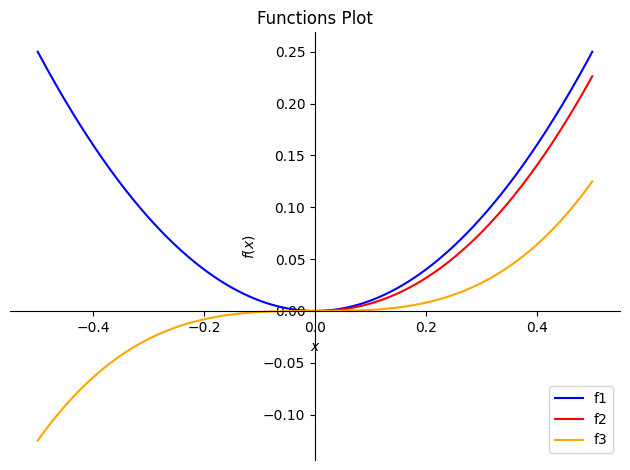

In [64]:
f1 = x**2
f2 = x**sy.Rational(15, 7) # We want a symbolic exponent, not a float
# The above gives complex results for x < 0. The version below prevents this,
# but it complicates some intermediate results.
# f2 = sy.real_root(x, 7)**15
f3 = x**3


plot_range = (x, -1/2, 1/2)
p = sy.plotting.plot(f1, f2, f3, plot_range, show=False, legend=True)
p[0].line_color = 'blue'
p[0].label = 'f1'
p[1].line_color = 'red'
p[1].label = 'f2'
p[2].line_color = 'orange'
p[2].label = 'f3'
p.title = 'Functions Plot'

p.show()

If you substitute one of this fractional powers in a Taylor polynomial you get an approximation to the function, but this is **not** a Taylor polynomial (which requires natural numbers as exponents).

In [65]:
f = sy.sin(f2)

display(Math(f"f(x) = {latex(f)}"))

<IPython.core.display.Math object>

In [66]:
f_series = sy.series(f, x, 0, 10).removeO()
display(Math(f"{latex(f_series)}"))

<IPython.core.display.Math object>

We can visualize the resulting approximation (only for x > 0 for reasons explained above).

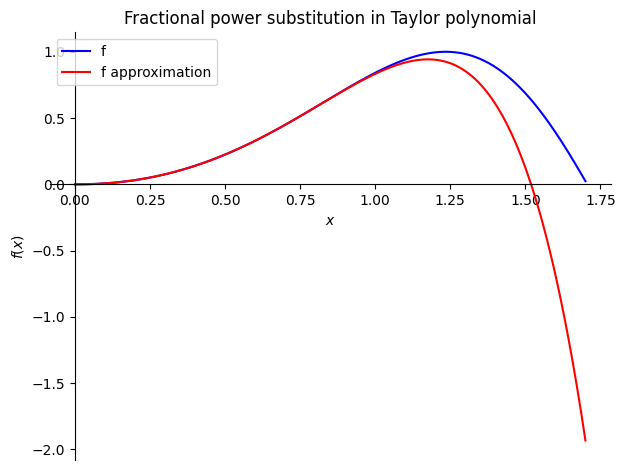

In [68]:
plot_range = (x, -0.1, 1.7)
p = sy.plotting.plot(f, f_series, plot_range, show=False, legend=True)
p[0].line_color = 'blue'
p[0].label = 'f'
p[1].line_color = 'red'
p[1].label = 'f approximation'
p.title = 'Fractional power substitution in Taylor polynomial'

p.show()

## Optional: Laurent expansion with negative powers

In some cases, even when a function has a vertical asymptote at a point we can extend to those cases the idea of Taylor polynomials. We will illustrate the **Laurent expansion** of a real function with a vertical asymptote at the origin. Let's define our function $f(x)$.

In [72]:
f = sy.cos(x) / x**6
display(Math(f"f(x) = {sy.latex(f)}"))

<IPython.core.display.Math object>

In this simple example you can visualize the Laurent expansion of $f(x)$ around $x=0$ simply by considering the Taylor polynomial of the numerator and dividing it by $x^6$. SymPy's `series` function can handle this by specifying the expansion point and the desired order for the positive powers. It will then automatically handle the negative powers.

In [73]:
laurent_f = sy.series(f, x, 0, 6)
display(Math(f"L(x) = {sy.latex(laurent_f)}"))

<IPython.core.display.Math object>

We can visually confirm that this negative powers expansion provides a good approximation to the function's behavior near the origin. We need to remove the `O(x^6)` term for plotting a numerical approximation.

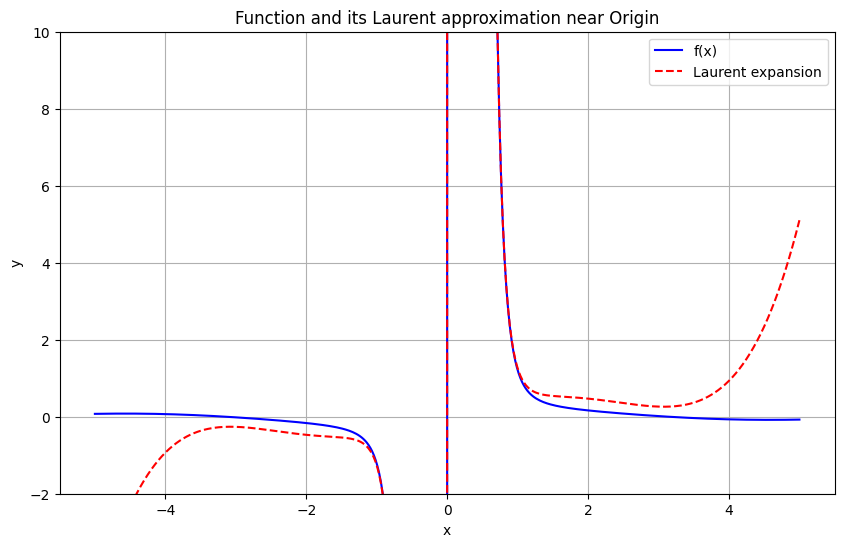

In [84]:
import numpy as np
import matplotlib.pyplot as plt

# Create numerical versions of the function and its Laurent series
f_laurent_num = sy.lambdify(x, f, 'numpy')

# Remove the Big O term for numerical evaluation of the series
laurent_f_clean = laurent_f.removeO()
laurent_f_num = sy.lambdify(x, laurent_f_clean, 'numpy')

# Define the range for plotting, avoiding x=0 where the pole is.
xs = np.linspace(-5, 5, 400)

# Filter out values very close to the pole for better plotting
xs = xs[np.abs(xs) > 0.05]

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(xs, f_laurent_num(xs), label='f(x)', color='blue', linestyle='-')
ax.plot(xs, laurent_f_num(xs), label=f'Laurent expansion', color='red', linestyle='--')

ax.set_ylim(-2, 10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Function and its Laurent approximation near Origin')
ax.legend()
ax.grid(True)
plt.show()

Things get more interesting when both numerator and denominator have non trivial Taylor polynomials.  

In [79]:
f = sy.sin(x) / sy.log(1 + x**8)
display(Math(f"f(x) = {sy.latex(f)}"))

<IPython.core.display.Math object>

Even in this case sympy can handle this kind of *polynomial division* for us.  
**Note:** this is not the usual polynomial division you may know. Why? In a sense, because here *lower order terms come first*.

In [82]:
laurent_f = sy.series(f, x, 0, 6)
display(Math(f"L(x) = {sy.latex(laurent_f)}"))

<IPython.core.display.Math object>

Make sure you visualize the approximation we have obtained near the origin. What are your thoughts about it?